# *Gephyrocapsa huxleyi* Ecosystem Model

## Figures for Jackson Page-Roth's Master's Thesis

### Parameters:
| Symbol | Description |
|--------|-------------|
| **P** | *E. huxleyi* concentration (cells mL-1) |
| **B** | *Sulfitobacter* D7 concentration (cells mL-1) |
| **D** | Dead *E. huxleyi* cells (cells mL-1) |
| **u_P, u_B** | Growth rates (day-1) |
| **k_P, k_B** | Carrying capacities (cells mL-1) |
| **phi_B** | D7 virulence (mL cell-1 day-1) |
| **beta_B** | D7 burst size (cells cell-1) |
| **delta_P** | *E. hux* natural death rate (day-1) |
| **lambda_D** | Dead cell organic dissolution rate (day-1) |
| **x_B** | Dead-cell scaling of phi_B (mL cell-1) |

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import matplotlib as mpl
import cartopy.crs as ccrs
import multiprocessing
import warnings
import arviz as az
import pymc as pm
import pytensor.tensor as pt
from pytensor.graph import Apply, Op
from scipy.integrate import solve_ivp
import matplotlib.cm as cm
from datetime import timedelta
import os
warnings.filterwarnings('ignore', category=RuntimeWarning)
try:
    multiprocessing.set_start_method('fork', force=True)
except ValueError:
    pass

# ── Global settings ───────────────────────────────────────────────────────────
MODE             = 'publish'  # 'test' | 'medium' | 'publish'
USE_SAVED_TRACES = True       # True  -> load .nc files; False -> run sampler
OVERWRITE_TRACES = False      # True  -> save new traces after sampling

colors = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000']

# Figure 1a

In [2]:
fp1a = 'data/chlorophyll/cmems_mod_glo_bgc_my_0.25deg_P1M-m_1782417984886.nc'
ds1a = xr.open_dataset(fp1a)
chl_mean = ds1a["chl"].mean(dim="time").drop("depth")

/var/folders/mp/cspgvq_d2h13_l03bp7hsr0r0000gn/T/ipykernel_8794/2274231047.py:3: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  chl_mean = ds1a["chl"].mean(dim="time").drop("depth")


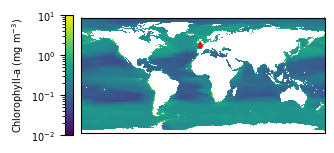

In [3]:
fig, ax = plt.subplots(figsize=(3.25, 2), subplot_kw={"projection": ccrs.PlateCarree()})

norm = mcolors.LogNorm(vmin=0.01, vmax=10)
p = chl_mean.plot(
    ax=ax, transform=ccrs.PlateCarree(),
    rasterized=True, norm=norm, add_colorbar=False
)

lon, lat = -4.217, 50.25
ax.scatter(lon, lat, transform=ccrs.PlateCarree(),
           color='red', marker='^', s=10)

fig.subplots_adjust(left=0.2, right=0.95, top=0.95, bottom=0.05)
cbar_ax = fig.add_axes([0.15, 0.2, 0.025, 0.6])
cbar = fig.colorbar(p, cax=cbar_ax)
cbar.set_label(r"Chlorophyll-a (mg m$^{-3}$)", size=7)
cbar.ax.yaxis.set_label_position('left')
cbar.ax.yaxis.tick_left()
plt.savefig('figures/fig01a.pdf', dpi=600)

# Figure 1b

In [4]:
fp1c = 'data/ESSD_Coccolithophores_revised_2013.xlsx'
df1c = pd.read_excel(fp1c, sheet_name='All datapoints')
df1c = df1c.loc[
    (df1c['Institute'] == 'Western Channel Observatory') &
    (df1c['Species/lowest classification'] == 'Emiliania huxleyi'),
    ['Year', 'Month ', 'Day', 'Species/lowest classification', 'Biovolume Category', 'Cells/l']
].copy()
df1c.rename(columns={'Month ': 'Month'}, inplace=True)
df1c['Date'] = pd.to_datetime({'year': df1c['Year'], 'month': df1c['Month'], 'day': df1c['Day']})
df1c = df1c.set_index('Date')
df1c['Cells/mL'] = (df1c['Cells/l'] / 1000).round()
df1c['Cells/mL'] = df1c['Cells/mL'].clip(lower=1).fillna(1)
df1c['MonthStart'] = df1c.index.to_period('M').to_timestamp()

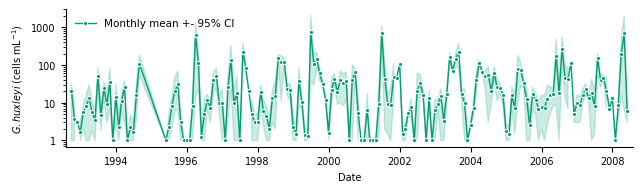

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 2))
sns.lineplot(
    data=df1c, x='MonthStart', y='Cells/mL',
    errorbar=('ci', 95), color=colors[2], linewidth=1,
    marker='o', markersize=3, ax=ax,
    label='Monthly mean +- 95% CI'
)
ax.set_xlim(df1c['MonthStart'].min() - timedelta(days=60),
            df1c['MonthStart'].max() + timedelta(days=60))
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.set_xlabel('Date', size=7)
ax.set_ylabel(r'$\it{G. huxleyi}$ (cells mL$^{-1})$', size=7)
ax.legend(frameon=False, loc="upper left")
sns.despine()
plt.tight_layout()
plt.savefig('figures/fig01b.png', dpi=600, bbox_inches="tight")

# Figure 3

## Setup — Data, Priors, and Functions

In [6]:
fp3 = 'data/ehux379_d7.csv'
df3 = pd.read_csv(fp3)
df3 = df3.loc[df3['exp'] == 5]

PRESETS = {
    'test':    (2000,  2000,  4),
    'medium':  (10000, 10000, 4),
    'publish': (50000, 50000, 4),
}
DRAWS, TUNE, CHAINS = PRESETS[MODE]
CORES = 1
print('Mode=%s  Draws=%d  Tune=%d  Chains=%d  Cores=%d'
      % (MODE, DRAWS, TUNE, CHAINS, CORES))

PRIORS_BASE = {
    'mu_P':     (4.4668e-01, 1.0),
    'delta_P':  (7.4131e-02, 1.0),
    'k_P':      (4.3652e+06, 1.0),
    'mu_B':     (4.8978e-01, 1.0),
    'k_B':      (4.3652e+07, 1.0),
    'beta_B':   (4.0500e+00, 1.0),
    'lambda_D': (4.8978e-01, 1.0),
    'P0':       (1.2303e+05, 1.0),
    'B0_mono':  (2.6915e+04, 1.0),
    'B0_co':    (1.3804e+05, 1.0),
    'D_N0':     (8.5114e+03, 1.0),
    'D_B0':     (1.0715e+04, 1.0),
}
PRIORS_MOD   = {**PRIORS_BASE, 'x':         (2.1878e-14, 1.0)}
PRIORS_CONST = {**PRIORS_BASE, 'phi_const': (1.9498e-08, 1.0)}
print('Priors defined.')
print('  Modulated  (%d params): includes x'         % len(PRIORS_MOD))
print('  Constant   (%d params): includes phi_const' % len(PRIORS_CONST))

Mode=publish  Draws=50000  Tune=50000  Chains=4  Cores=1
Priors defined.
  Modulated  (13 params): includes x
  Constant   (13 params): includes phi_const


In [7]:
def get_obs_exp(df, exp_id, with_d7):
    """
    Extract observations for one experiment / treatment.

    Parameters
    ----------
    df      : DataFrame with columns:
              time, ehux, bacteria, sytox+, exp, d7_present (True/False)
    exp_id  : value to match in the 'exp' column
    with_d7 : bool

    Returns
    -------
    dict with keys: t, P, B, D, D_mask, has_dead
    """
    subset = df[
        (df['exp'] == exp_id) &
        (df['d7_present'].astype(bool) == bool(with_d7))
    ].copy().sort_values('time').reset_index(drop=True)

    t     = subset['time'].values.astype(float)
    P     = subset['ehux'].values.astype(float)
    B     = subset['bacteria'].values.astype(float)
    D_raw = subset['sytox+'].values.astype(float)

    D_mask   = np.isfinite(D_raw) & (D_raw > 0)
    has_dead = bool(D_mask.any())

    return {'t': t, 'P': P, 'B': B, 'D': D_raw,
            'D_mask': D_mask, 'has_dead': has_dead}

print('get_obs_exp defined.')

get_obs_exp defined.


In [8]:
def ode_rhs(t, y, p, with_d7, phi_mode):
    """
    Right-hand side of the phytoplankton-bacteria ODE system.
    State vector y = [P, B, D_N, D_B]
    phi_mode: 'mod' -> phi = x * (D_N + D_B)
              'const' -> phi = phi_const
    with_d7: if False, phi is forced to 0 (monoculture)
    """
    P, B, D_N, D_B = np.maximum(y, 0.0)
    D = D_N + D_B
    if with_d7:
        phi = p['x'] * D if phi_mode == 'mod' else p['phi_const']
    else:
        phi = 0.0
    dP   = p['mu_P']    * P * (1 - P / p['k_P']) - p['delta_P'] * P - phi * P * B
    dB   = p['mu_B']    * B * (1 - B / p['k_B']) + p['beta_B'] * phi * P * B
    dD_N = p['delta_P'] * P                       - p['lambda_D'] * D_N
    dD_B = phi * P * B                            - p['lambda_D'] * D_B
    return [dP, dB, dD_N, dD_B]


def run_ode(params, t_out, with_d7, phi_mode):
    """
    Integrate the ODE. Returns (P, B, D_N, D_B) or None on failure.
    """
    B0 = params['B0_co'] if with_d7 else params['B0_mono']
    y0 = [params['P0'], B0, params['D_N0'], params['D_B0']]
    t_eval = np.unique(t_out)
    t_span = (0.0, float(t_eval.max()) + 0.1)
    for method in ('RK45', 'Radau'):
        try:
            sol = solve_ivp(
                lambda t, y: ode_rhs(t, y, params, with_d7, phi_mode),
                t_span, y0, method=method, t_eval=t_eval,
                rtol=1e-6, atol=1e-9)
            if sol.success and np.all(np.isfinite(sol.y)):
                interp = lambda row: np.interp(t_out, t_eval, row)
                return (np.maximum(interp(sol.y[0]), 1.0),
                        np.maximum(interp(sol.y[1]), 1.0),
                        np.maximum(interp(sol.y[2]), 1.0),
                        np.maximum(interp(sol.y[3]), 1.0))
        except Exception:
            continue
    return None

print('ODE functions defined.')

ODE functions defined.


In [9]:
def ll_log(obs, pred, sigma=0.3, eps=1e-6):
    """Log-likelihood on log10-transformed data."""
    obs  = np.clip(obs,  eps, None)
    pred = np.clip(pred, eps, None)
    r    = np.log10(obs) - np.log10(pred)
    v    = -0.5 * np.sum((r / sigma)**2 + np.log(2 * np.pi * sigma**2))
    return float(v) if np.isfinite(v) else -1e30

print('ll_log defined.')

ALL_ERROR_COMPONENTS = ['ehux_mono', 'ehux_co', 'bacteria_co', 'dead_co']


class EhuxOp(Op):
    """
    PyTensor Op wrapping the ODE log-likelihood.
    phi_mode : 'mod' | 'const'
    error_components : list of components to include in likelihood.
    """
    def __init__(self, phi_mode, priors, obs_m, obs_c, error_components=None):
        self.phi_mode  = phi_mode
        self.priors    = priors
        self.obs_m     = obs_m
        self.obs_c     = obs_c
        self.error_components = (error_components if error_components is not None
                                 else ALL_ERROR_COMPONENTS)

    def make_node(self, theta):
        return Apply(self, [pt.as_tensor_variable(theta)], [pt.dscalar()])

    def perform(self, node, inputs, outputs):
        theta = inputs[0]
        names = list(self.priors.keys())
        obs_m = self.obs_m
        obs_c = self.obs_c
        ec    = self.error_components

        if not np.all(np.isfinite(theta)):
            outputs[0][0] = np.array(-1e30); return

        params = {n: float(v) for n, v in zip(names, theta)}
        if any(params[k] <= 0 for k in names):
            outputs[0][0] = np.array(-1e30); return

        res_m = None
        if 'ehux_mono' in ec:
            res_m = run_ode(params, obs_m['t'], with_d7=False, phi_mode=self.phi_mode)
            if res_m is None:
                outputs[0][0] = np.array(-1e30); return

        res_c = None
        if any(c in ec for c in ('ehux_co', 'bacteria_co', 'dead_co')):
            res_c = run_ode(params, obs_c['t'], with_d7=True, phi_mode=self.phi_mode)
            if res_c is None:
                outputs[0][0] = np.array(-1e30); return

        total = 0.0
        if 'ehux_mono'   in ec: total += ll_log(obs_m['P'], res_m[0])
        if 'ehux_co'     in ec: total += ll_log(obs_c['P'], res_c[0])
        if 'bacteria_co' in ec:
            mask = obs_c['t'] != 0
            total += ll_log(obs_c['B'][mask], res_c[1][mask])
        if 'dead_co' in ec and obs_c['has_dead']:
            mask  = obs_c['D_mask']
            D_tot = res_c[2][mask] + res_c[3][mask]
            total += ll_log(obs_c['D'][mask], D_tot)

        outputs[0][0] = np.array(total)

print('EhuxOp defined.')

ll_log defined.
EhuxOp defined.


In [10]:
def sanitise(trace):
    """Replace non-finite posterior values with NaN."""
    clean = trace.copy()
    for var in clean.posterior.data_vars:
        arr = clean.posterior[var].values.astype(float)
        arr[~np.isfinite(arr)] = np.nan
        clean.posterior[var] = xr.DataArray(
            arr, dims=clean.posterior[var].dims,
            coords=clean.posterior[var].coords)
    return clean


def sample_model(phi_mode, priors, obs_m, obs_c, error_components=None, mode=None):
    """Build and sample the PyMC model."""
    if mode is not None:
        draws, tune, chains = PRESETS[mode]
        cores = CORES
    else:
        draws, tune, chains, cores = DRAWS, TUNE, CHAINS, CORES

    op = EhuxOp(phi_mode, priors, obs_m, obs_c, error_components)
    with pm.Model():
        rvs   = {name: pm.LogNormal(name, mu=np.log(centre), sigma=sigma)
                 for name, (centre, sigma) in priors.items()}
        theta = pt.as_tensor_variable([rvs[n] for n in priors])
        pm.Potential('likelihood', op(theta))
        trace = pm.sample(
            draws=draws, tune=tune, chains=chains, cores=cores,
            step=pm.DEMetropolisZ(),
            progressbar=True, return_inferencedata=True)
    return sanitise(trace)


def compute_confidence_bands(trace, priors, phi_mode, t_dense, n_samples=200, seed=None):
    """
    Draw posterior samples and compute 5/50/95 percentile bands.
    Returns dict with keys: mono_P, co_P, co_B, co_D_N, co_D_B, co_D
    each with _lo, _med, _hi suffixes.
    """
    post  = trace.posterior
    names = list(priors.keys())
    flat  = {n: post[n].values.reshape(-1) for n in names}
    finite_mask = np.ones(len(next(iter(flat.values()))), dtype=bool)
    for v in flat.values():
        finite_mask &= np.isfinite(v)
    finite_idx = np.where(finite_mask)[0]

    rng    = np.random.default_rng(seed)
    n_draw = min(n_samples, len(finite_idx))
    idx    = rng.choice(finite_idx, size=n_draw, replace=False)

    store = {'mono_P': [], 'co_P': [], 'co_B': [], 'co_D_N': [], 'co_D_B': []}
    for i in idx:
        p  = {n: float(flat[n][i]) for n in names}
        rm = run_ode(p, t_dense, with_d7=False, phi_mode=phi_mode)
        rc = run_ode(p, t_dense, with_d7=True,  phi_mode=phi_mode)
        if rm is not None: store['mono_P'].append(rm[0])
        if rc is not None:
            store['co_P'].append(rc[0]); store['co_B'].append(rc[1])
            store['co_D_N'].append(rc[2]); store['co_D_B'].append(rc[3])

    bands = {}
    for key, curves in store.items():
        if not curves: continue
        arr = np.array(curves)
        for pct, suf in zip((5, 50, 95), ('_lo', '_med', '_hi')):
            bands[key + suf] = np.percentile(arr, pct, axis=0)
    if 'co_D_N_lo' in bands and 'co_D_B_lo' in bands:
        for suf in ('_lo', '_med', '_hi'):
            bands['co_D' + suf] = bands['co_D_N' + suf] + bands['co_D_B' + suf]
    return bands

print('sanitise, sample_model, compute_confidence_bands defined.')

def r2_log(obs, pred, eps=1e-6):
    obs  = np.log10(np.clip(obs,  eps, None))
    pred = np.log10(np.clip(pred, eps, None))
    ss_res = np.sum((obs - pred) ** 2)
    ss_tot = np.sum((obs - np.mean(obs)) ** 2)
    return 1 - ss_res / ss_tot

sanitise, sample_model, compute_confidence_bands defined.


In [11]:
obs_m_df3 = get_obs_exp(df3, 5, with_d7=False)
obs_c_df3 = get_obs_exp(df3, 5, with_d7=True)

max_t_df3   = max(obs_m_df3['t'].max(), obs_c_df3['t'].max())
t_dense_df3 = np.linspace(0, max_t_df3, 300)

print('df3 observations extracted.')
print('  Monoculture time points : %d  (t = %s)' % (len(obs_m_df3['t']), obs_m_df3['t']))
print('  Co-culture  time points : %d  (t = %s)' % (len(obs_c_df3['t']), obs_c_df3['t']))
print('  Dead-cell data present  : %s' % obs_c_df3['has_dead'])
print('  Dense grid              : 0 -> %.1f days  (%d points)' % (max_t_df3, len(t_dense_df3)))

df3 observations extracted.
  Monoculture time points : 36  (t = [ 0.  0.  0.  1.  1.  1.  2.  2.  2.  3.  3.  3.  4.  4.  4.  5.  5.  5.
  6.  6.  6.  7.  7.  7.  8.  8.  8.  9.  9.  9. 10. 10. 10. 11. 11. 11.])
  Co-culture  time points : 36  (t = [ 0.  0.  0.  1.  1.  1.  2.  2.  2.  3.  3.  3.  4.  4.  4.  5.  5.  5.
  6.  6.  6.  7.  7.  7.  8.  8.  8.  9.  9.  9. 10. 10. 10. 11. 11. 11.])
  Dead-cell data present  : True
  Dense grid              : 0 -> 11.0 days  (300 points)


## Constant Phi — All Four Error Components

In [12]:
EC_FULL = ['ehux_mono', 'ehux_co', 'bacteria_co', 'dead_co']
TRACE_CONST_PATH = 'data/trace_const.nc'

if USE_SAVED_TRACES and os.path.exists(TRACE_CONST_PATH):
    trace_const_full = az.from_netcdf(TRACE_CONST_PATH)
    print('Loaded trace_const_full from:', TRACE_CONST_PATH)
else:
    trace_const_full = sample_model(
        phi_mode         = 'const',
        priors           = PRIORS_CONST,
        obs_m            = obs_m_df3,
        obs_c            = obs_c_df3,
        error_components = EC_FULL,
    )
    print('Constant phi sampling complete.')
    if OVERWRITE_TRACES:
        trace_const_full.to_netcdf(TRACE_CONST_PATH)
        print('Saved to:', TRACE_CONST_PATH)

Loaded trace_const_full from: data/trace_const.nc


In [13]:
param_names_const = list(PRIORS_CONST.keys())
summary_const = az.summary(
    trace_const_full, var_names=param_names_const,
    stat_funcs=None, round_to=10,
)
print('\n' + '='*70)
print('  Constant phi  |  All four error components')
print('='*70)
print(summary_const.to_string())
print('='*70)
print()
print('Parameter comparison: prior centre vs posterior median')
print('  %-12s  %14s  %14s' % ('Parameter', 'Prior centre', 'Post. median'))
print('  ' + '-'*44)
for name in param_names_const:
    centre = PRIORS_CONST[name][0]
    median = float(trace_const_full.posterior[name].median())
    print('  %-12s  %14.4e  %14.4e' % (name, centre, median))


  Constant phi  |  All four error components
                   mean            sd        hdi_3%       hdi_97%     mcse_mean       mcse_sd     ess_bulk     ess_tail     r_hat
mu_P       7.429212e-01  1.084349e-01  5.410791e-01  9.425939e-01  2.134543e-03  1.509520e-03  2582.319047  4727.755919  1.002477
delta_P    2.992056e-02  1.405704e-02  6.698804e-03  5.626217e-02  2.480591e-04  1.754202e-04  2874.423874  3726.883909  1.002546
k_P        6.801524e+06  1.201997e+06  4.772918e+06  9.065180e+06  2.306858e+04  1.636932e+04  2804.245460  4415.004532  1.001081
mu_B       6.185225e-01  6.752136e-02  4.912609e-01  7.444796e-01  1.919030e-03  1.357279e-03  1347.770339  1155.790610  1.003806
k_B        5.838295e+08  3.277196e+08  1.823147e+08  1.120872e+09  6.932578e+06  4.902713e+06  2511.707071  3456.170359  1.001113
beta_B     2.128215e+00  1.446766e+00  1.899930e-01  4.816236e+00  4.695215e-02  3.390495e-02  1060.591688  1520.762206  1.003792
lambda_D   5.645488e-01  1.474920e-01  2.974

## Figure 3 — Phi Sweep

In [14]:
# ── User inputs ───────────────────────────────────────────────────────────────
PHI_MIN = 5e-9
PHI_MAX = 1.75e-8
N_LINES = 5

# Pull posterior medians from trace_const_full
median_params = {name: float(trace_const_full.posterior[name].median())
                 for name in list(PRIORS_CONST.keys())}

PHI_VALUES_SWEEP = np.linspace(PHI_MIN, PHI_MAX, N_LINES)

results_sweep_phi = []
for phi in PHI_VALUES_SWEEP:
    p = {**median_params, 'phi_const': phi}
    sol = run_ode(p, t_dense_df3, with_d7=True, phi_mode='const')
    results_sweep_phi.append(sol)

sol_mono_phi = run_ode(median_params, t_dense_df3, with_d7=False, phi_mode='const')

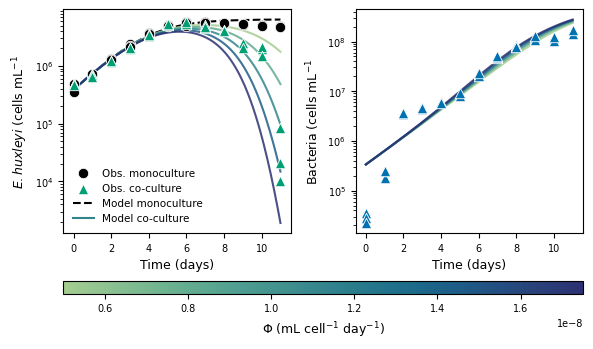

In [15]:
cmap = sns.color_palette("crest", as_cmap=True)
norm = mcolors.Normalize(vmin=PHI_MIN, vmax=PHI_MAX)

fig, ax = plt.subplots(1, 2, figsize=(6, 3.85))

sns.scatterplot(data=obs_m_df3, x='t', y='P', ax=ax[0],
                label='Obs. monoculture', color='black', zorder=2)
sns.scatterplot(data=obs_c_df3, x='t', y='P', ax=ax[0],
                label='Obs. co-culture', marker='^', color=colors[2], zorder=2)
sns.scatterplot(data=obs_c_df3, x='t', y='B', ax=ax[1],
                marker='^', color=colors[4], zorder=2)

if sol_mono_phi is not None:
    P_m, B_m, DN_m, DB_m = sol_mono_phi
    sns.lineplot(x=t_dense_df3, y=P_m, ax=ax[0],
                 color='black', ls='--', label='Model monoculture', zorder=0)

for phi, sol in zip(PHI_VALUES_SWEEP, results_sweep_phi):
    if sol is None: continue
    P_c, B_c, DN_c, DB_c = sol
    color = cmap(norm(phi))
    sns.lineplot(x=t_dense_df3, y=P_c, ax=ax[0], color=color, alpha=0.85, zorder=1)
    sns.lineplot(x=t_dense_df3, y=B_c, ax=ax[1], color=color, alpha=0.85, zorder=1)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
handles, labels = ax[0].get_legend_handles_labels()
proxy_co = Line2D([0], [0], color=cmap(norm(np.mean([PHI_MIN, PHI_MAX]))),
                  label='Model co-culture')
ax[0].legend(handles=handles + [proxy_co], labels=labels + ['Model co-culture'],
             loc='lower left', frameon=False)

ax[0].set_xlabel('Time (days)'); ax[1].set_xlabel('Time (days)')
ax[0].set_ylabel(r'$\it{E. huxleyi}$ (cells mL$^{-1}$')
ax[1].set_ylabel('Bacteria (cells mL$^{-1}$')
ax[0].set_yscale('log'); ax[1].set_yscale('log')
ax[0].set_xticks(np.arange(0, 12, 2)); ax[1].set_xticks(np.arange(0, 12, 2))

plt.tight_layout()
cbar = plt.colorbar(sm, ax=ax, label=r'$\Phi$ (mL cell$^{-1}$ day$^{-1}$)',
                    orientation="horizontal", aspect=40, pad=0.15)
# plt.savefig('figures/fig03.pdf', dpi=600, bbox_inches="tight")

# Figure 4 — Modulated Phi

In [16]:
TRACE_MOD_PATH = 'data/trace_mod.nc'

if USE_SAVED_TRACES and os.path.exists(TRACE_MOD_PATH):
    trace_df3_mod = az.from_netcdf(TRACE_MOD_PATH)
    print('Loaded trace_df3_mod from:', TRACE_MOD_PATH)
else:
    trace_df3_mod = sample_model(
        phi_mode         = 'mod',
        priors           = PRIORS_MOD,
        obs_m            = obs_m_df3,
        obs_c            = obs_c_df3,
        error_components = ['ehux_mono', 'ehux_co', 'bacteria_co', 'dead_co'],
    )
    print('Modulated phi sampling complete.')
    if OVERWRITE_TRACES:
        trace_df3_mod.to_netcdf(TRACE_MOD_PATH)
        print('Saved to:', TRACE_MOD_PATH)

Loaded trace_df3_mod from: data/trace_mod.nc


In [17]:
param_names_mod = list(PRIORS_MOD.keys())
summary_df3_mod = az.summary(
    trace_df3_mod, var_names=param_names_mod,
    stat_funcs=None, round_to=10,
)
print('\n' + '='*70)
print('  df3  |  Modulated phi (x*D)  |  All four error components')
print('='*70)
print(summary_df3_mod.to_string())
print('='*70)

print('\n  Parameter comparison: prior centre vs posterior median')
print('  %-12s  %14s  %14s' % ('Parameter', 'Prior centre', 'Post. median'))
print('  ' + '-'*44)
for name in param_names_mod:
    centre = PRIORS_MOD[name][0]
    median = float(trace_df3_mod.posterior[name].median())
    print('  %-12s  %14.4e  %14.4e' % (name, centre, median))


  df3  |  Modulated phi (x*D)  |  All four error components
                  mean            sd        hdi_3%       hdi_97%     mcse_mean       mcse_sd     ess_bulk     ess_tail     r_hat
mu_P      8.110189e-01  1.255608e-01  5.843787e-01  1.052361e+00  2.590252e-03  1.831812e-03  2318.087415  3777.039727  1.002642
delta_P   4.485063e-02  1.267475e-02  2.300370e-02  6.859446e-02  2.459083e-04  1.739025e-04  2595.371242  4528.179875  1.001436
k_P       5.816604e+06  8.776456e+05  4.277961e+06  7.401626e+06  1.902457e+04  1.381207e+04  2344.279713  2972.978657  1.001946
mu_B      6.651534e-01  6.415283e-02  5.475397e-01  7.869396e-01  1.489915e-03  1.053694e-03  1834.157382  4424.274346  1.006174
k_B       2.772626e+08  1.336443e+08  1.027363e+08  5.204901e+08  3.319944e+06  2.352756e+06  1827.785672  2883.143598  1.002309
beta_B    2.967237e+00  2.433720e+00  1.311031e-01  7.223650e+00  4.816337e-02  3.406054e-02  2365.193850  3748.201247  1.002232
lambda_D  2.752422e-01  1.231447e-01

In [18]:
bands_df3_mod = compute_confidence_bands(
    trace=trace_df3_mod, priors=PRIORS_MOD, phi_mode='mod',
    t_dense=t_dense_df3, n_samples=200, seed=42,
)
D_lo  = bands_df3_mod['co_D_N_lo']  + bands_df3_mod['co_D_B_lo']
D_med = bands_df3_mod['co_D_N_med'] + bands_df3_mod['co_D_B_med']
D_hi  = bands_df3_mod['co_D_N_hi']  + bands_df3_mod['co_D_B_hi']
print('Confidence bands computed.')

Confidence bands computed.


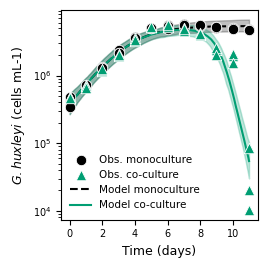

In [19]:
fig, ax = plt.subplots(figsize=(2.75, 2.75))
sns.scatterplot(data=obs_m_df3, x='t', y='P',
                color=colors[7], zorder=5, marker='o', ax=ax, label='Obs. monoculture')
sns.scatterplot(data=obs_c_df3, x='t', y='P',
                color=colors[2], zorder=5, marker='^', ax=ax, label='Obs. co-culture')
sns.lineplot(x=t_dense_df3, y=bands_df3_mod['mono_P_med'],
             ax=ax, color='black', ls='--', label='Model monoculture')
sns.lineplot(x=t_dense_df3, y=bands_df3_mod['co_P_med'],
             ax=ax, color=colors[2], label='Model co-culture')
ax.fill_between(t_dense_df3, bands_df3_mod['mono_P_lo'], bands_df3_mod['mono_P_hi'],
                alpha=0.25, color=colors[7])
ax.fill_between(t_dense_df3, bands_df3_mod['co_P_lo'], bands_df3_mod['co_P_hi'],
                alpha=0.25, color=colors[2])
ax.set_xlabel('Time (days)')
ax.set_ylabel(r'$\it{G. huxleyi}$ (cells mL-1)')
ax.set_yscale('log')
ax.legend(frameon=False, loc='lower left')
ax.set_xticks(np.arange(0, 12, 2))
plt.tight_layout()
# plt.savefig('figures/fig04a.pdf', dpi=600, bbox_inches="tight")
plt.show()

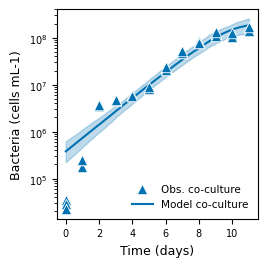

In [20]:
fig, ax = plt.subplots(figsize=(2.75, 2.75))
sns.scatterplot(data=obs_c_df3, x='t', y='B',
                color=colors[4], zorder=5, marker='^', ax=ax, label='Obs. co-culture')
sns.lineplot(x=t_dense_df3, y=bands_df3_mod['co_B_med'],
             ax=ax, color=colors[4], label='Model co-culture')
ax.fill_between(t_dense_df3, bands_df3_mod['co_B_lo'], bands_df3_mod['co_B_hi'],
                alpha=0.25, color=colors[4])
ax.set_xlabel('Time (days)')
ax.set_ylabel('Bacteria (cells mL-1)')
ax.set_yscale('log')
ax.legend(frameon=False, loc='lower right')
ax.set_xticks(np.arange(0, 12, 2))
plt.tight_layout()
# plt.savefig('figures/fig04b.pdf', dpi=600, bbox_inches="tight")
plt.show()

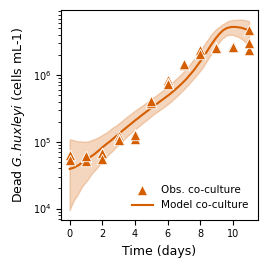

In [21]:
fig, ax = plt.subplots(figsize=(2.75, 2.75))
sns.scatterplot(data=obs_c_df3, x='t', y='D',
                color=colors[5], zorder=5, marker='^', ax=ax, label='Obs. co-culture')
sns.lineplot(x=t_dense_df3, y=D_med, ax=ax, color=colors[5], label='Model co-culture')
ax.fill_between(t_dense_df3, D_lo, D_hi, alpha=0.25, color=colors[5])
ax.set_xlabel('Time (days)')
ax.set_ylabel(r'Dead $\it{G. huxleyi}$ (cells mL-1)')
ax.set_yscale('log')
ax.legend(frameon=False, loc='lower right')
ax.set_xticks(np.arange(0, 12, 2))
plt.tight_layout()
# plt.savefig('figures/fig04c.pdf', dpi=600, bbox_inches="tight")
plt.show()

# Model Comparison

In [22]:
def compute_loglik_samples(trace, priors, phi_mode, obs_m, obs_c,
                            error_components, n_samples=500, seed=42):
    """Evaluate the total log-likelihood at n_samples posterior draws."""
    post  = trace.posterior
    names = list(priors.keys())
    flat  = {n: post[n].values.reshape(-1) for n in names}
    finite_mask = np.ones(len(next(iter(flat.values()))), dtype=bool)
    for v in flat.values():
        finite_mask &= np.isfinite(v)
    finite_idx = np.where(finite_mask)[0]

    rng = np.random.default_rng(seed)
    idx = rng.choice(finite_idx, size=min(n_samples, len(finite_idx)), replace=False)

    ec = error_components
    logliks = []
    for i in idx:
        params = {n: float(flat[n][i]) for n in names}
        res_m, res_c = None, None
        if 'ehux_mono' in ec:
            res_m = run_ode(params, obs_m['t'], with_d7=False, phi_mode=phi_mode)
        if any(c in ec for c in ('ehux_co', 'bacteria_co', 'dead_co')):
            res_c = run_ode(params, obs_c['t'], with_d7=True, phi_mode=phi_mode)
        if (('ehux_mono' in ec and res_m is None) or
            (any(c in ec for c in ('ehux_co', 'bacteria_co', 'dead_co')) and res_c is None)):
            continue
        total = 0.0
        if 'ehux_mono'   in ec: total += ll_log(obs_m['P'], res_m[0])
        if 'ehux_co'     in ec: total += ll_log(obs_c['P'], res_c[0])
        if 'bacteria_co' in ec:
            mask = obs_c['t'] != 0
            total += ll_log(obs_c['B'][mask], res_c[1][mask])
        if 'dead_co' in ec and obs_c['has_dead']:
            mask  = obs_c['D_mask']
            D_tot = res_c[2][mask] + res_c[3][mask]
            total += ll_log(obs_c['D'][mask], D_tot)
        logliks.append(total)
    return np.array(logliks)


ll_const = compute_loglik_samples(
    trace_const_full, PRIORS_CONST, 'const',
    obs_m_df3, obs_c_df3, EC_FULL, n_samples=500, seed=42)

ll_mod = compute_loglik_samples(
    trace_df3_mod, PRIORS_MOD, 'mod',
    obs_m_df3, obs_c_df3, EC_FULL, n_samples=500, seed=42)

print('Log-likelihoods computed.')
print('  Constant phi  -- mean: %.2f   median: %.2f   SD: %.2f'
      % (ll_const.mean(), np.median(ll_const), ll_const.std()))
print('  Modulated phi -- mean: %.2f   median: %.2f   SD: %.2f'
      % (ll_mod.mean(), np.median(ll_mod), ll_mod.std()))
print('  Delta median (mod - const): %.2f' % (np.median(ll_mod) - np.median(ll_const)))

Log-likelihoods computed.
  Constant phi  -- mean: 9.29   median: 9.45   SD: 2.37
  Modulated phi -- mean: 9.60   median: 10.01   SD: 2.50
  Delta median (mod - const): 0.56


/var/folders/mp/cspgvq_d2h13_l03bp7hsr0r0000gn/T/ipykernel_8794/1549525995.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=ll_df, x='Model', y='Log-likelihood',


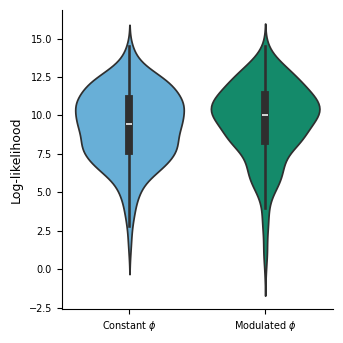

In [23]:
ll_df = pd.DataFrame({
    'Log-likelihood': np.concatenate([ll_const, ll_mod]),
    'Model': ([r'Constant $\phi$'] * len(ll_const) +
              [r'Modulated $\phi$'] * len(ll_mod)),
})
fig, ax = plt.subplots(figsize=(3.5, 3.5))
sns.violinplot(data=ll_df, x='Model', y='Log-likelihood',
               palette=[colors[1], colors[2]], inner='box', ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Log-likelihood')
sns.despine()
plt.tight_layout()
# plt.savefig('figures/model_comparison.pdf', dpi=600, bbox_inches='tight')
plt.show()

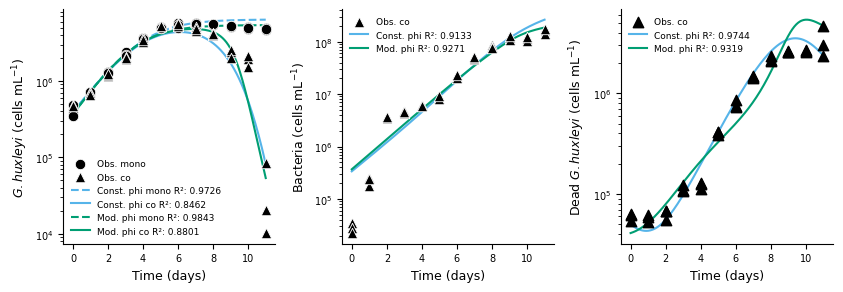

In [24]:
# Publish-level posterior medians — from trace_const_full and trace_df3_mod
params_const = {
    'mu_P':      7.3671e-01, 'delta_P':   2.7818e-02, 'k_P':       6.6351e+06,
    'mu_B':      6.2220e-01, 'k_B':       5.0028e+08, 'beta_B':    1.7687e+00,
    'lambda_D':  5.5567e-01, 'P0':        3.8864e+05, 'B0_mono':   2.7456e+04,
    'B0_co':     3.3608e+05, 'D_N0':      1.9984e+04, 'D_B0':      3.0045e+04,
    'phi_const': 1.1538e-08,
}
params_mod = {
    'mu_P':     8.0456e-01, 'delta_P':  4.3287e-02, 'k_P':      5.7045e+06,
    'mu_B':     6.6355e-01, 'k_B':      2.4397e+08, 'beta_B':   2.3001e+00,
    'lambda_D': 2.6258e-01, 'P0':       3.6569e+05, 'B0_mono':  2.6683e+04,
    'B0_co':    3.6759e+05, 'D_N0':     1.6927e+04, 'D_B0':     2.4086e+04,
    'x':        3.5029e-15,
}

sol_const_mono = run_ode(params_const, t_dense_df3, with_d7=False, phi_mode='const')
sol_const_co   = run_ode(params_const, t_dense_df3, with_d7=True,  phi_mode='const')
sol_mod_mono   = run_ode(params_mod,   t_dense_df3, with_d7=False, phi_mode='mod')
sol_mod_co     = run_ode(params_mod,   t_dense_df3, with_d7=True,  phi_mode='mod')

COLOR_CONST = colors[1]
COLOR_MOD   = colors[2]
COLOR_OBS   = colors[7]

fig, axes = plt.subplots(1, 3, figsize=(8.5, 3.0))

ax = axes[0]
sns.scatterplot(data=obs_m_df3, x='t', y='P', color=COLOR_OBS, marker='o', ax=ax, label='Obs. mono', zorder=5)
sns.scatterplot(data=obs_c_df3, x='t', y='P', color=COLOR_OBS, marker='^', ax=ax, label='Obs. co', zorder=5)
if sol_const_mono is not None:
    ax.plot(t_dense_df3, sol_const_mono[0], color=COLOR_CONST, ls='--', label='Const. phi mono R²: 0.9726')
if sol_const_co is not None:
    ax.plot(t_dense_df3, sol_const_co[0],   color=COLOR_CONST,           label='Const. phi co R²: 0.8462')
if sol_mod_mono is not None:
    ax.plot(t_dense_df3, sol_mod_mono[0],   color=COLOR_MOD,   ls='--', label='Mod. phi mono R²: 0.9843')
if sol_mod_co is not None:
    ax.plot(t_dense_df3, sol_mod_co[0],     color=COLOR_MOD,             label='Mod. phi co R²: 0.8801')
ax.set_yscale('log'); ax.set_xlabel('Time (days)')
ax.set_ylabel(r'$\it{G. huxleyi}$ (cells mL$^{-1}$)')
ax.set_xticks(np.arange(0, max_t_df3 + 1, 2))
ax.legend(frameon=False, fontsize=6.5)

ax = axes[1]
sns.scatterplot(data=obs_c_df3, x='t', y='B', color=COLOR_OBS, marker='^', ax=ax, label='Obs. co', zorder=5)
if sol_const_co is not None:
    ax.plot(t_dense_df3, sol_const_co[1], color=COLOR_CONST, label='Const. phi R²: 0.9133')
if sol_mod_co is not None:
    ax.plot(t_dense_df3, sol_mod_co[1],   color=COLOR_MOD,   label='Mod. phi R²: 0.9271')
ax.set_yscale('log'); ax.set_xlabel('Time (days)')
ax.set_ylabel('Bacteria (cells mL$^{-1}$)')
ax.set_xticks(np.arange(0, max_t_df3 + 1, 2))
ax.legend(frameon=False, fontsize=6.5)

ax = axes[2]
if obs_c_df3['has_dead']:
    mask = obs_c_df3['D_mask']
    ax.scatter(obs_c_df3['t'][mask], obs_c_df3['D'][mask],
               color=COLOR_OBS, marker='^', label='Obs. co', zorder=5)
if sol_const_co is not None:
    ax.plot(t_dense_df3, sol_const_co[2] + sol_const_co[3], color=COLOR_CONST, label='Const. phi R²: 0.9744')
if sol_mod_co is not None:
    ax.plot(t_dense_df3, sol_mod_co[2] + sol_mod_co[3],     color=COLOR_MOD,   label='Mod. phi R²: 0.9319')
ax.set_yscale('log'); ax.set_xlabel('Time (days)')
ax.set_ylabel(r'Dead $\it{G. huxleyi}$ (cells mL$^{-1}$)')
ax.set_xticks(np.arange(0, max_t_df3 + 1, 2))
ax.legend(frameon=False, fontsize=6.5)

sns.despine()
plt.tight_layout()
# plt.savefig('figures/model_comparison_fit.pdf', dpi=600, bbox_inches='tight')
plt.show()

In [25]:
for label, params, phi_mode in [
    ('Constant φ', params_const, 'const'),
    ('Modulated φ', params_mod,  'mod'),
]:
    sol_m = run_ode(params, obs_m_df3['t'], with_d7=False, phi_mode=phi_mode)
    sol_c = run_ode(params, obs_c_df3['t'], with_d7=True,  phi_mode=phi_mode)

    mask_b = obs_c_df3['t'] != 0
    mask_d = obs_c_df3['D_mask']

    r2_P_mono = r2_log(obs_m_df3['P'], sol_m[0])
    r2_P_co   = r2_log(obs_c_df3['P'], sol_c[0])
    r2_B_co   = r2_log(obs_c_df3['B'][mask_b], sol_c[1][mask_b])
    D_tot     = sol_c[2][mask_d] + sol_c[3][mask_d]
    r2_D_co   = r2_log(obs_c_df3['D'][mask_d], D_tot)

    print(f'\n{label}')
    print(f'  R² P mono : {r2_P_mono:.4f}')
    print(f'  R² P co   : {r2_P_co:.4f}')
    print(f'  R² B co   : {r2_B_co:.4f}')
    print(f'  R² D co   : {r2_D_co:.4f}')


Constant φ
  R² P mono : 0.9726
  R² P co   : 0.8462
  R² B co   : 0.9133
  R² D co   : 0.9744

Modulated φ
  R² P mono : 0.9843
  R² P co   : 0.8801
  R² B co   : 0.9271
  R² D co   : 0.9319


# Figure 5 — Ecosystem Model

In [26]:
params_eco = {
    'P0':       1.0000e+03, 'mu_P':     7.9016e-01, 'k_P':      5.0000e+08, 'delta_P':  4.4706e-02,
    'B0':       1.0000e+04, 'mu_B':     6.7141e-01, 'k_B':      5.0000e+08, 'beta_B':   2.2290e+00, 'x_B':      3.6061e-14,
    'V0':       1.0000e+05, 'phi_V':    3.0900e-08, 'k_V':      1.0000e+10, 'beta_V':   3.0600e+02,
    'Z0':       1.0000e+01, 'Gmax':     1.2500e+00, 'k_Z':      4.0000e+06, 'k_m':      1.1000e+01,
    'D0':       4.0000e+02, 'lambda_D': 2.9388e-01, 
}
T_END_ECO   = 15.0
t_dense_eco = np.linspace(0, T_END_ECO, 600)


def ode_rhs_eco(t, y, p):
    P, B, V, Z, D_nat, D_bact, D_vir, D_zoop = np.maximum(y, 0.0)
    phi_B = p['x_B'] * (D_nat + D_bact + D_vir + D_zoop*0)
    phi_V = p['phi_V']
    graz  = p['Gmax'] * P * (1-Z/p['k_Z']) / (p['k_m'] + P) * Z
    dP      = (p['mu_P'] * P * (1 - P / p['k_P']) - p['delta_P'] * P
               - phi_B * P * B - phi_V * P * V * (1-V/p['k_V']) - graz)
    dB      = p['mu_B'] * B * (1 - B / p['k_B']) + p['beta_B'] * phi_B * P * B
    dV      = p['beta_V'] * phi_V * P * V * (1-V/p['k_V'])
    dZ      = graz
    dD_nat  = p['delta_P'] * P  - p['lambda_D'] * D_nat
    dD_bact = phi_B * P * B     - p['lambda_D'] * D_bact
    dD_vir  = phi_V * P * V     - p['lambda_D'] * D_vir
    dD_zoop = graz              - p['lambda_D'] * D_zoop
    return [dP, dB, dV, dZ, dD_nat, dD_bact, dD_vir, dD_zoop]


def run_ode_eco(p, t_out):
    y0     = [p['P0'], p['B0'], p['V0'], p['Z0'], p['D0'], 0.0, 0.0, 0.0]
    t_eval = np.unique(t_out)
    t_span = (0.0, float(t_eval.max()) + 0.1)
    for method in ('RK45', 'Radau'):
        try:
            sol = solve_ivp(lambda t, y: ode_rhs_eco(t, y, p),
                            t_span, y0, method=method, t_eval=t_eval,
                            rtol=1e-6, atol=1e-9)
            if sol.success and np.all(np.isfinite(sol.y)):
                interp = lambda row: np.interp(t_out, t_eval, row)
                return [np.maximum(interp(sol.y[i]), 1.0) for i in range(8)]
        except Exception:
            continue
    return None

In [27]:
from scipy.stats.qmc import LatinHypercube, scale

N_SAMPLES = 5000
PARAM_RANGES = {
    'x_B':    (1e-14, 1e-13),
    'phi_V':  (1e-10, 5e-8),
    'beta_V': (200,   800),
    'Gmax':   (0.4,   5),
    'k_m':    (4800,     48000),
}
PARAM_NAMES = list(PARAM_RANGES.keys())
N_PARAMS    = len(PARAM_NAMES)

sampler   = LatinHypercube(d=N_PARAMS, seed=42)
unit_cube = sampler.random(n=N_SAMPLES)
lo = [PARAM_RANGES[k][0] for k in PARAM_NAMES]
hi = [PARAM_RANGES[k][1] for k in PARAM_NAMES]
samples = scale(unit_cube, lo, hi)

results_sweep = []
params_sweep  = []
for row in samples:
    p = {**params_eco}
    for name, val in zip(PARAM_NAMES, row):
        p[name] = val
    res = run_ode_eco(p, t_dense_eco)
    results_sweep.append(res)
    params_sweep.append(p)

n_ok = sum(r is not None for r in results_sweep)
print(f'Completed {N_SAMPLES} runs -- {n_ok} succeeded, {N_SAMPLES - n_ok} failed.')

Completed 5000 runs -- 5000 succeeded, 0 failed.


In [28]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

N_CLUSTERS = 3

features  = []
valid_idx = []

for i, res in enumerate(results_sweep):
    if res is None: continue
    P_t, B_t, V_t, Z_t, D_nat, D_bact, D_vir, D_zoop = res
    p = params_sweep[i]
    phi_B_t = p['x_B'] * (D_nat + D_bact + D_vir + D_zoop)
    graz_t  = p['Gmax'] * P_t / (p['k_m'] + P_t) * Z_t
    flux_nat  = p['delta_P'] * P_t
    flux_bact = phi_B_t      * P_t * B_t
    flux_vir  = p['phi_V']   * P_t * V_t
    flux_zoop = graz_t
    total_sum = (np.sum(flux_nat) + np.sum(flux_bact) +
                 np.sum(flux_vir) + np.sum(flux_zoop) + 1e-30)

    frac_nat  = float(np.sum(flux_nat)  / total_sum)
    frac_bact = float(np.sum(flux_bact) / total_sum)
    frac_vir  = float(np.sum(flux_vir)  / total_sum)
    frac_zoop = float(np.sum(flux_zoop) / total_sum)

    features.append([frac_nat, frac_bact, frac_vir, frac_zoop])
    valid_idx.append(i)
    
features  = np.array(features)
valid_idx = np.array(valid_idx)

scaler      = StandardScaler()
feat_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20)
labels = kmeans.fit_predict(feat_scaled)

print('Clustering complete. Cluster sizes:')
for k in range(N_CLUSTERS):
    print(f'  Cluster {k}: {(labels == k).sum()} runs')

frac_df = pd.DataFrame(features, columns=['Natural', 'Bacterial', 'Viral', 'Grazing'])
frac_df['cluster'] = labels


Clustering complete. Cluster sizes:
  Cluster 0: 2921 runs
  Cluster 1: 1917 runs
  Cluster 2: 162 runs


In [29]:
representatives = {}
for k in range(N_CLUSTERS):
    mask     = labels == k
    centroid = kmeans.cluster_centers_[k]
    dists    = np.linalg.norm(feat_scaled[mask] - centroid, axis=1)
    local_i  = np.argmin(dists)
    global_i = valid_idx[np.where(mask)[0][local_i]]
    representatives[k] = global_i

# ── Sort clusters by grazing fraction descending after k-means ───────────────
cluster_means = frac_df.groupby('cluster').mean()
sort_order    = cluster_means['Grazing'].argsort()[::-1].values  
# sort_order[0] = old cluster label that had highest grazing

label_map = {old: new for new, old in enumerate(sort_order)}

# Remap labels array and frac_df
labels            = np.array([label_map[l] for l in labels])
frac_df['cluster'] = labels

# Remap representatives dict
representatives = {label_map[old_k]: idx
                   for old_k, idx in representatives.items()}

print(frac_df.groupby('cluster').mean().round(3).to_string())

print('Cluster sizes after sorting:')
for k in range(N_CLUSTERS):
    print(f'  Cluster {k}: {(labels == k).sum()} runs')
    
for k in range(N_CLUSTERS):
    p = params_sweep[representatives[k]]
    print(f'Cluster {k}')
    print('\n'.join([f'  {n}={p[n]:.1e}' for n in PARAM_NAMES]))
    print()

         Natural  Bacterial  Viral  Grazing
cluster                                    
0          0.055      0.005  0.044    0.897
1          0.050      0.668  0.103    0.178
2          0.056      0.029  0.847    0.068
Cluster sizes after sorting:
  Cluster 0: 2921 runs
  Cluster 1: 162 runs
  Cluster 2: 1917 runs
Cluster 0
  x_B=4.2e-14
  phi_V=4.0e-08
  beta_V=2.4e+02
  Gmax=3.6e+00
  k_m=4.8e+04

Cluster 1
  x_B=5.6e-14
  phi_V=3.5e-09
  beta_V=4.4e+02
  Gmax=1.7e+00
  k_m=4.2e+04

Cluster 2
  x_B=4.6e-14
  phi_V=1.8e-08
  beta_V=4.3e+02
  Gmax=1.4e+00
  k_m=1.1e+04



/var/folders/mp/cspgvq_d2h13_l03bp7hsr0r0000gn/T/ipykernel_8794/2044396356.py:16: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax_top.set_ylim(0, 5e6)


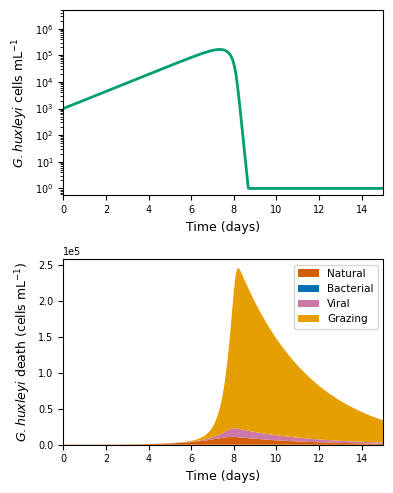

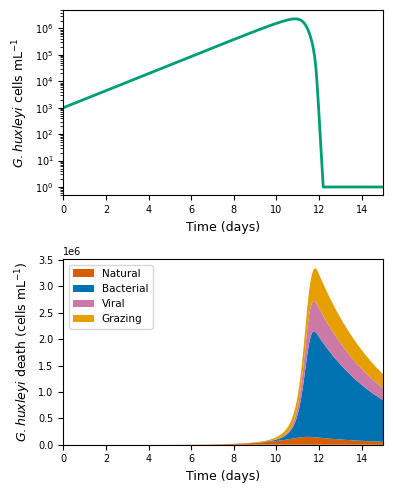

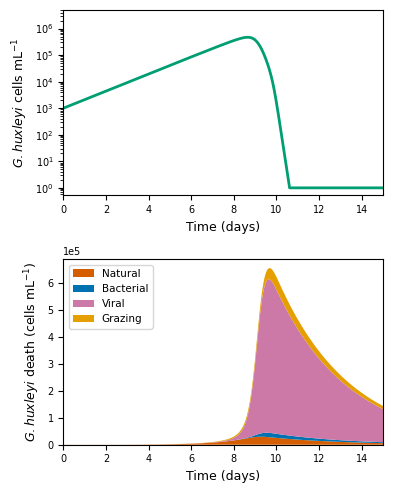

In [30]:
SUBFIG_LABELS = 'abcdefghij'

for k in range(N_CLUSTERS):
    i   = representatives[k]
    res = results_sweep[i]
    p   = params_sweep[i]
    P_t, B_t, V_t, Z_t, D_nat, D_bact, D_vir, D_zoop = res

    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(4, 5))

    ax_top.plot(t_dense_eco, P_t, color=colors[2], lw=2)
    ax_top.set_yscale('log')
    ax_top.set_xlabel('Time (days)')
    ax_top.set_ylabel(r'$\it{G. huxleyi}$ cells mL$^{-1}$')
    ax_top.set_xlim(0, T_END_ECO)
    ax_top.set_ylim(0, 5e6)

    ax_bot.stackplot(
        t_dense_eco, D_nat, D_bact, D_vir, D_zoop,
        labels=['Natural', 'Bacterial', 'Viral', 'Grazing'],
        colors=[colors[5], colors[4], colors[6], colors[0]],
    )
    ax_bot.set_xlabel('Time (days)')
    ax_bot.set_ylabel(r'$\it{G. huxleyi}$ death (cells mL$^{-1}$)')
    ax_bot.set_xlim(0, T_END_ECO)
    # ax_bot.set_yscale('log')
    ax_bot.ticklabel_format(style='sci', scilimits=(0, 0), axis='y')
    ax_bot.legend(loc='best')

    plt.tight_layout()
    fname = f'figures/fig05{SUBFIG_LABELS[k]}.pdf'
    # plt.savefig(fname, dpi=600, bbox_inches='tight')
    # print(f'Saved: {fname}')
    plt.show()

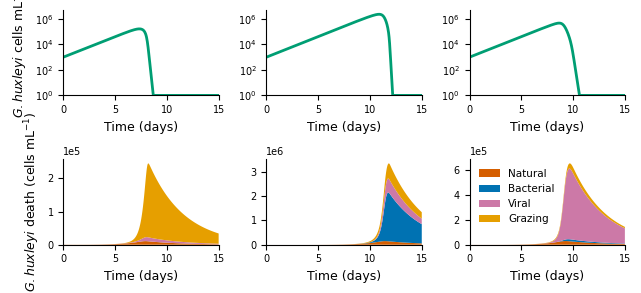

In [31]:
fig, axes = plt.subplots(2, N_CLUSTERS, figsize=(2.16 * N_CLUSTERS, 3))

for k in range(N_CLUSTERS):
    i   = representatives[k]
    res = results_sweep[i]
    p   = params_sweep[i]
    P_t, B_t, V_t, Z_t, D_nat, D_bact, D_vir, D_zoop = res

    ax_top = axes[0, k]
    ax_bot = axes[1, k]

    # ── Top: P trajectory ─────────────────────────────────────────────────────
    ax_top.plot(t_dense_eco, P_t, color=colors[2], lw=2)
    ax_top.set_yscale('log')
    ax_top.set_xlabel('Time (days)')
    ax_top.set_xlim(0, T_END_ECO)
    ax_top.set_ylim(1, 5e6)
    if k == 0:
        ax_top.set_ylabel(r'$\it{G. huxleyi}$ cells mL$^{-1}$')

    # ── Bottom: stacked dead cells ────────────────────────────────────────────
    ax_bot.stackplot(
        t_dense_eco, D_nat, D_bact, D_vir, D_zoop,
        labels=['Natural', 'Bacterial', 'Viral', 'Grazing'],
        colors=[colors[5], colors[4], colors[6], colors[0]],
    )
    ax_bot.set_xlabel('Time (days)')
    ax_bot.set_xlim(0, T_END_ECO)
    # ax_bot.set_yscale('log')
    # ax_bot.set_ylim(0, 3e7)
    ax_bot.ticklabel_format(style='sci', scilimits=(0, 0), axis='y')
    if k == 0:
        ax_bot.set_ylabel(r'$\it{G. huxleyi}$ death (cells mL$^{-1}$)')
    if k == N_CLUSTERS-1:
        ax_bot.legend(loc='best', frameon=False)

sns.despine()
plt.tight_layout()
plt.savefig('figures/fig05.pdf', dpi=600, bbox_inches='tight')
plt.show()


# Ecosystem Model — Grazing Inhibition by Dead Cell Metabolites

In [32]:
params_eco = {
    'mu_P':     7.9016e-01, 'k_P':      5.8149e+06, 'delta_P':  4.4706e-02,
    'mu_B':     6.7141e-01, 'k_B':      2.3603e+08, 'beta_B':   2.2290e+00,
    'x_B':      4.6061e-14,
    'phi_V':    2.4000e-08, 'beta_V':   5.6000e+02,
    'Gmax':     2.8000e+00, 'k_m':      1.5000e+01,
    'z_Z':      3e-4,
    'lambda_D': 2.9388e-01,
    'P0':       3.7198e+03, 'B0':       3.5052e+04, 'V0':       1.0000e+06,
    'Z0':       5.0000e+00, 'D0':       4.0000e+02,
}
T_END_ECO   = 12.0
t_dense_eco = np.linspace(0, T_END_ECO, 600)


def ode_rhs_eco(t, y, p):
    P, B, V, Z, D_nat, D_bact, D_vir, D_zoop = np.maximum(y, 0.0)
    phi_B        = p['x_B'] * (D_nat + D_bact + D_vir + D_zoop)
    phi_V        = p['phi_V']
    D_metabolite = D_nat + D_bact + D_vir
    graz  = p['Gmax'] * np.exp(-p['z_Z'] * D_metabolite) * P / (p['k_m'] + P) * Z
    dP      = (p['mu_P'] * P * (1 - P / p['k_P']) - p['delta_P'] * P
               - phi_B * P * B - phi_V * P * V - graz)
    dB      = p['mu_B'] * B * (1 - B / p['k_B']) + p['beta_B'] * phi_B * P * B
    dV      = p['beta_V'] * phi_V * P * V
    dZ      = p['Gmax'] * np.exp(-p['z_Z'] * D_metabolite) * P / (p['k_m'] + P) * Z
    dD_nat  = p['delta_P'] * P  - p['lambda_D'] * D_nat
    dD_bact = phi_B * P * B     - p['lambda_D'] * D_bact
    dD_vir  = phi_V * P * V     - p['lambda_D'] * D_vir
    dD_zoop = graz              - p['lambda_D'] * D_zoop
    return [dP, dB, dV, dZ, dD_nat, dD_bact, dD_vir, dD_zoop]


def run_ode_eco(p, t_out):
    y0     = [p['P0'], p['B0'], p['V0'], p['Z0'], p['D0'], 0.0, 0.0, 0.0]
    t_eval = np.unique(t_out)
    t_span = (0.0, float(t_eval.max()) + 0.1)
    for method in ('RK45', 'Radau'):
        try:
            sol = solve_ivp(lambda t, y: ode_rhs_eco(t, y, p),
                            t_span, y0, method=method, t_eval=t_eval,
                            rtol=1e-6, atol=1e-9)
            if sol.success and np.all(np.isfinite(sol.y)):
                interp = lambda row: np.interp(t_out, t_eval, row)
                return [np.maximum(interp(sol.y[i]), 1.0) for i in range(8)]
        except Exception:
            continue
    return None


res_eco = run_ode_eco(params_eco, t_dense_eco)
if res_eco is None:
    print('ODE integration failed.')
else:
    print('ODE solved.')

ODE solved.


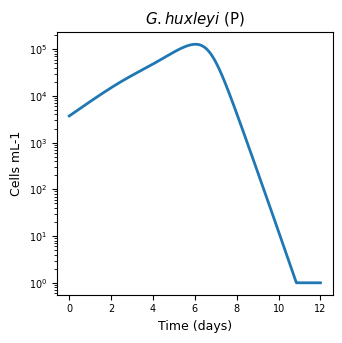

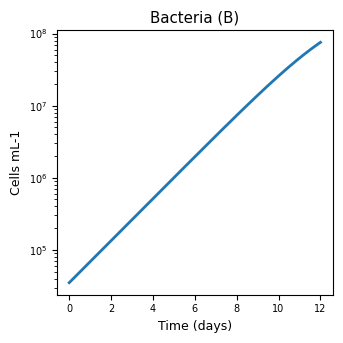

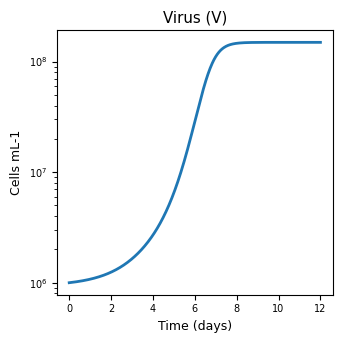

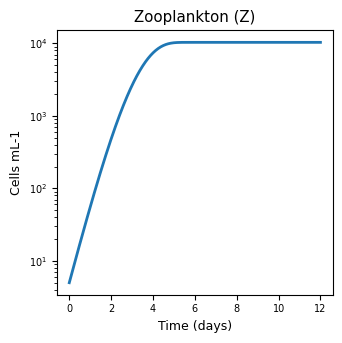

In [33]:
POP_LABELS = [
    (r'$\it{G. huxleyi}$ (P)', 0),
    ('Bacteria (B)',            1),
    ('Virus (V)',               2),
    ('Zooplankton (Z)',         3),
]
for label, idx in POP_LABELS:
    fig, ax = plt.subplots(figsize=(3.5, 3.5))
    if res_eco is not None:
        ax.plot(t_dense_eco, res_eco[idx], lw=2)
        ax.set_yscale('log')
    ax.set_title(label)
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Cells mL-1')
    plt.tight_layout()
    plt.show()

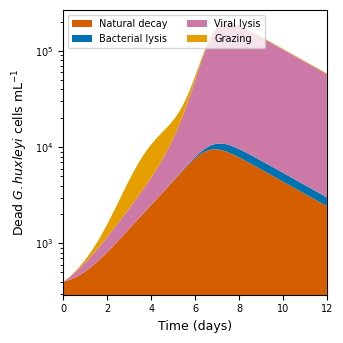

In [34]:
fig, ax = plt.subplots(figsize=(3.5, 3.5))
if res_eco is not None:
    P_t, B_t, V_t, Z_t, D_nat, D_bact, D_vir, D_zoop = res_eco
    ax.stackplot(
        t_dense_eco, D_nat, D_bact, D_vir, D_zoop,
        labels=['Natural decay', 'Bacterial lysis', 'Viral lysis', 'Grazing'],
        colors=[colors[5], colors[4], colors[6], colors[0]],
    )
    ax.set_ylabel(r'Dead $\it{G. huxleyi}$ cells mL$^{-1}$')
    ax.set_xlabel('Time (days)')
    ax.set_yscale('log')
    ax.set_xlim(0, T_END_ECO)
    ax.legend(loc='upper left', ncol=2, fontsize=7)
plt.tight_layout()
# plt.savefig('figures/ecosystem_dead.pdf', dpi=600, bbox_inches='tight')
plt.show()

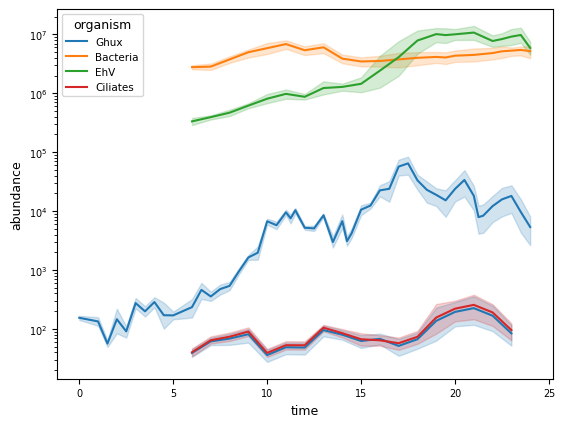

In [ ]:
df=pd.read_excel('data/AQUACOSM_VIMS-Ehux_CoreData-2.xlsx')
df['Taxonomic Group'].unique()
ghux = df.loc[df['Taxonomic Group'] == 'Neuks_HighSS']
bacteria = df.loc[df['Taxonomic Group'] == 'Bacteria']
ehv = df.loc[df['Taxonomic Group'] == 'EhV']

files = {
    "Fjord": "data/ciliates/Dataset 8.csv",
    "Bag 1": "data/ciliates/Dataset 1.csv",
    "Bag 2": "data/ciliates/Dataset 2.csv",
    "Bag 3": "data/ciliates/Dataset 3.csv",
    "Bag 4": "data/ciliates/Dataset 4.csv",
    "Bag 5": "data/ciliates/Dataset 5.csv",
    "Bag 6": "data/ciliates/Dataset 6.csv",
    "Bag 7": "data/ciliates/Dataset 7.csv",
}

dfs = []
for label, filepath in files.items():
    df = pd.read_csv(filepath, names=["time", "abundance"])
    df["sample"] = label
    dfs.append(df)

ciliates = pd.concat(dfs, axis=0).reset_index(drop=True)
ciliates['organism'] = 'Ciliates'
ciliates['abundance']=ciliates['abundance']/1000
sns.lineplot(data=ciliates.loc[ciliates['sample']!='fjord'], x='time', y='abundance', errorbar=('ci', 95))
sns.lineplot(data=ciliates.loc[ciliates['sample']=='fjord'], x='time', y='abundance', errorbar=('ci', 95))
def to_long(df, organism_name):
    df = df.drop(columns="Taxonomic Group")
    df = df.melt(id_vars="Day",
                 var_name="sample",
                 value_name="abundance")
    df = df.rename(columns={"Day": "time"})
    df["organism"] = organism_name                   
    return df

ghux_long     = to_long(ghux, "Ghux")
bacteria_long = to_long(bacteria, "Bacteria")
ehv_long      = to_long(ehv, "EhV")

all_long = pd.concat([ghux_long, bacteria_long, ehv_long, ciliates], axis=0).reset_index(drop=True)
sns.lineplot(all_long.loc[all_long['sample']!='Fjord'], x='time', y='abundance', hue='organism', errorbar=('ci', 95))
# sns.lineplot(all_long.loc[all_long['sample']=='fjord'], x='time', y='abundance', hue='organism', errorbar=('ci', 95))
plt.yscale('log')


In [ ]:

# # ╔══════════════════════════════════════════════════════════════════════════════╗
# # ║  CELL — Extract pooled (all-bag) observations from all_long, excluding Fjord ║
# # ╚══════════════════════════════════════════════════════════════════════════════╝
# # all_long has columns: time, sample, abundance, organism
# # organism values expected: 'Ghux', 'Bacteria', 'EhV', 'Ciliates'
# # sample values expected: 'Bag 1' ... 'Bag 7', 'Fjord'
# #
# # Treats each of the 7 bags as a replicate, exactly like replicate flow
# # cytometry measurements in the infection model. All bags are pooled into a
# # single set of (t, value) pairs per organism — the likelihood function
# # doesn't care that multiple values share a timepoint, same as before.

# EXCLUDE_SAMPLES = ['Fjord']   # case-sensitive; adjust if your labels differ

# def get_obs_eco_pooled(df_long, exclude=EXCLUDE_SAMPLES):
#     """
#     Pool observations across all bags (replicates), excluding named samples.

#     Parameters
#     ----------
#     df_long : DataFrame with columns ['time', 'sample', 'abundance', 'organism']
#     exclude : list of sample labels to drop (e.g. ['Fjord'])

#     Returns
#     -------
#     dict with keys: t_P, P, t_B, B, t_V, V, t_Z, Z
#     Each (t, value) pair is one bag's measurement at that day — multiple
#     bags contribute multiple points at the same nominal time, which is
#     treated as replicate noise by the log-likelihood, same as flow
#     cytometry replicates in the infection model.
#     """
#     sub = df_long[~df_long['sample'].isin(exclude)]

#     def extract(org):
#         s = sub[sub['organism'] == org].dropna(subset=['abundance'])
#         s = s.sort_values('time')
#         return s['time'].values.astype(float), s['abundance'].values.astype(float)

#     t_P, P = extract('Ghux')
#     t_B, B = extract('Bacteria')
#     t_V, V = extract('EhV')
#     t_Z, Z = extract('Ciliates')

#     return {'t_P': t_P, 'P': P, 't_B': t_B, 'B': B,
#             't_V': t_V, 'V': V, 't_Z': t_Z, 'Z': Z}

# obs_eco = get_obs_eco_pooled(all_long)

# print('Samples found in all_long:', sorted(all_long['sample'].unique()))
# print('Organisms found in all_long:', sorted(all_long['organism'].unique()))
# print()
# print('Pooled observations (all bags, Fjord excluded):')
# for name in ('P', 'B', 'V', 'Z'):
#     t_arr = obs_eco[f't_{name}']
#     n_bags_at_t0 = np.sum(t_arr == t_arr.min()) if len(t_arr) else 0
#     print(f'  {name}: {len(t_arr)} total points across bags '
#           f'(~{n_bags_at_t0} replicates at t={t_arr.min() if len(t_arr) else "NA"})')

# all_times   = np.concatenate([obs_eco['t_P'], obs_eco['t_B'], obs_eco['t_V'], obs_eco['t_Z']])
# t_dense_eco_fit = np.linspace(0, all_times.max(), 300)
# print(f'\nDense grid: 0 -> {all_times.max():.1f} days ({len(t_dense_eco_fit)} points)')


# # ╔══════════════════════════════════════════════════════════════════════════════╗
# # ║  CELL — Priors for fitting — ALL parameters now sampled                    ║
# # ╚══════════════════════════════════════════════════════════════════════════════╝
# # Every parameter, including those previously fixed at the infection model's
# # posterior medians, is now a free parameter with a LogNormal prior. Centres
# # are taken from params_mod (the co-culture posterior medians) for the
# # infection-model parameters, and from literature/manual values for the
# # ecosystem-specific parameters. Initial conditions are centred on the
# # mean across bags at the earliest shared timepoint.

# def mean_at_earliest(t_arr, v_arr, fallback):
#     """Average value across all bags at the earliest shared timepoint."""
#     if len(t_arr) == 0:
#         return fallback
#     t0 = t_arr.min()
#     vals = v_arr[t_arr == t0]
#     return float(np.mean(vals)) if len(vals) else fallback

# P0_guess = mean_at_earliest(obs_eco['t_P'], obs_eco['P'], 1e3)
# B0_guess = mean_at_earliest(obs_eco['t_B'], obs_eco['B'], 1e4)
# V0_guess = mean_at_earliest(obs_eco['t_V'], obs_eco['V'], 1e5)
# Z0_guess = mean_at_earliest(obs_eco['t_Z'], obs_eco['Z'], 1e1)

# # (centre, sigma) for LogNormal priors — ALL parameters fitted
# PRIORS_ECO = {
#     # Previously fixed — now free, centred on infection model posteriors
#     'mu_P':     (params_mod['mu_P'],     1.0),
#     'k_P':      (params_mod['k_P'],      1.0),
#     'delta_P':  (params_mod['delta_P'],  1.0),
#     'mu_B':     (params_mod['mu_B'],     1.0),
#     'k_B':      (params_mod['k_B'],      1.0),
#     'beta_B':   (params_mod['beta_B'],   1.0),
#     'lambda_D': (params_mod['lambda_D'], 1.0),
#     # Ecosystem-specific
#     'x_B':      (3.6061e-14, 1.0),
#     'phi_V':    (3.0900e-08, 1.0),
#     'beta_V':   (3.0600e+02, 1.0),
#     'Gmax':     (1.2500e+00, 1.0),
#     'k_m':      (1.1000e+01, 1.0),
#     # Initial conditions
#     'P0':       (max(P0_guess, 1.0), 1.0),
#     'B0':       (max(B0_guess, 1.0), 1.0),
#     'V0':       (max(V0_guess, 1.0), 1.0),
#     'Z0':       (max(Z0_guess, 1.0), 1.0),
# }

# # D0 is not observed in the mesocosm data — kept fixed as a small constant
# D0_FIXED = 400.0

# print(f'Total fitted parameters: {len(PRIORS_ECO)}')
# print('\nPriors (centres):')
# for k, v in PRIORS_ECO.items():
#     print(f'  {k:<10} centre={v[0]:.3e}')


# # ╔══════════════════════════════════════════════════════════════════════════════╗
# # ║  CELL — Ecosystem ODE (fit version) — all parameters passed via p dict     ║
# # ╚══════════════════════════════════════════════════════════════════════════════╝
# # State vector: [P, B, V, Z, D_nat, D_bact, D_vir, D_zoop]
# # Uses simple Holling type II grazing (no metabolite inhibition), matching
# # the equations presented in the methods section.

# def ode_rhs_eco_fit(t, y, p):
#     P, B, V, Z, D_nat, D_bact, D_vir, D_zoop = np.maximum(y, 0.0)

#     phi_B = p['x_B'] * (D_nat + D_bact + D_vir + D_zoop)
#     phi_V = p['phi_V']
#     graz  = p['Gmax'] * P / (p['k_m'] + P) * Z

#     dP = (p['mu_P'] * P * (1 - P / p['k_P'])
#           - p['delta_P'] * P
#           - phi_B * P * B
#           - phi_V * P * V
#           - graz)
#     dB = p['mu_B'] * B * (1 - B / p['k_B']) + p['beta_B'] * phi_B * P * B
#     dV = p['beta_V'] * phi_V * P * V
#     dZ = graz

#     dD_nat  = p['delta_P'] * P  - p['lambda_D'] * D_nat
#     dD_bact = phi_B * P * B     - p['lambda_D'] * D_bact
#     dD_vir  = phi_V * P * V     - p['lambda_D'] * D_vir
#     dD_zoop = graz              - p['lambda_D'] * D_zoop

#     return [dP, dB, dV, dZ, dD_nat, dD_bact, dD_vir, dD_zoop]


# def run_ode_eco_fit(p, t_out):
#     """
#     Integrate the ecosystem ODE. Returns dict with P, B, V, Z arrays aligned
#     to t_out, or None on failure. D0 is fixed (not observed / not fitted).
#     """
#     y0 = [p['P0'], p['B0'], p['V0'], p['Z0'], D0_FIXED, 0.0, 0.0, 0.0]
#     t_eval = np.unique(t_out)
#     t_span = (0.0, float(t_eval.max()) + 0.1)

#     for method in ('RK45', 'Radau'):
#         try:
#             sol = solve_ivp(
#                 lambda t, y: ode_rhs_eco_fit(t, y, p),
#                 t_span, y0, method=method, t_eval=t_eval,
#                 rtol=1e-6, atol=1e-9)
#             if sol.success and np.all(np.isfinite(sol.y)):
#                 interp = lambda row: np.interp(t_out, t_eval, row)
#                 return {
#                     't': t_out,
#                     'P': np.maximum(interp(sol.y[0]), 1.0),
#                     'B': np.maximum(interp(sol.y[1]), 1.0),
#                     'V': np.maximum(interp(sol.y[2]), 1.0),
#                     'Z': np.maximum(interp(sol.y[3]), 1.0),
#                 }
#         except Exception:
#             continue
#     return None

# print('Ecosystem fit ODE functions defined (all parameters fitted).')


# # ╔══════════════════════════════════════════════════════════════════════════════╗
# # ║  CELL — PyTensor Op wrapping the ecosystem log-likelihood                  ║
# # ╚══════════════════════════════════════════════════════════════════════════════╝
# # Valid strings for error_components: 'P', 'B', 'V', 'Z'
# # All bags are already pooled into obs['t_P']/obs['P'] etc — replicate points
# # sharing a timepoint are handled naturally by evaluating the ODE once on the
# # union of times and comparing against every replicate observation.

# ALL_ECO_COMPONENTS = ['P', 'B', 'V', 'Z']


# class EcoOp(Op):
#     """
#     PyTensor Op wrapping the ecosystem ODE log-likelihood.

#     priors           : dict {name: (centre, sigma)} — ALL parameters, fitted
#     obs              : dict from get_obs_eco_pooled
#     error_components : list of organism codes to include (None -> all four)
#     """
#     def __init__(self, priors, obs, error_components=None):
#         self.priors = priors
#         self.obs    = obs
#         self.error_components = (error_components if error_components is not None
#                                  else ALL_ECO_COMPONENTS)

#     def make_node(self, theta):
#         return Apply(self, [pt.as_tensor_variable(theta)], [pt.dscalar()])

#     def perform(self, node, inputs, outputs):
#         theta = inputs[0]
#         names = list(self.priors.keys())
#         obs   = self.obs
#         ec    = self.error_components

#         if not np.all(np.isfinite(theta)):
#             outputs[0][0] = np.array(-1e30); return

#         p = {n: float(v) for n, v in zip(names, theta)}
#         if any(p[k] <= 0 for k in names):
#             outputs[0][0] = np.array(-1e30); return

#         # Union of all observation times needed across requested components
#         t_union = np.unique(np.concatenate([
#             obs[f't_{c}'] for c in ec if len(obs[f't_{c}']) > 0
#         ])) if ec else np.array([0.0])

#         res = run_ode_eco_fit(p, t_union)
#         if res is None:
#             outputs[0][0] = np.array(-1e30); return

#         total = 0.0
#         for c in ec:
#             t_obs = obs[f't_{c}']
#             v_obs = obs[c]
#             if len(t_obs) == 0:
#                 continue
#             v_pred = np.interp(t_obs, t_union, res[c])
#             total += ll_log(v_obs, v_pred)

#         outputs[0][0] = np.array(total)

# print('EcoOp defined (all parameters fitted).')


# # ╔══════════════════════════════════════════════════════════════════════════════╗
# # ║  CELL — Sampler                                                            ║
# # ╚══════════════════════════════════════════════════════════════════════════════╝

# def sample_eco_model(priors, obs, error_components=None, mode=None):
#     """
#     Build and sample the full ecosystem PyMC model.

#     mode : 'test' | 'medium' | 'publish' — overrides global DRAWS/TUNE/CHAINS
#            for this call only. Pass None to use the global preset.
#     """
#     if mode is not None:
#         draws, tune, chains = PRESETS[mode]
#         cores = CORES
#     else:
#         draws, tune, chains, cores = DRAWS, TUNE, CHAINS, CORES

#     op = EcoOp(priors, obs, error_components)
#     with pm.Model():
#         rvs   = {name: pm.LogNormal(name, mu=np.log(centre), sigma=sigma)
#                  for name, (centre, sigma) in priors.items()}
#         theta = pt.as_tensor_variable([rvs[n] for n in priors])
#         pm.Potential('likelihood', op(theta))
#         trace = pm.sample(
#             draws=draws, tune=tune, chains=chains, cores=cores,
#             step=pm.DEMetropolisZ(),
#             progressbar=True, return_inferencedata=True)
#     return sanitise(trace)


# TRACE_ECO_PATH = 'data/trace_eco_mesocosm.nc'

# if USE_SAVED_TRACES and os.path.exists(TRACE_ECO_PATH):
#     trace_eco = az.from_netcdf(TRACE_ECO_PATH)
#     print('Loaded trace_eco from:', TRACE_ECO_PATH)
# else:
#     trace_eco = sample_eco_model(
#         priors           = PRIORS_ECO,
#         obs              = obs_eco,
#         error_components = ALL_ECO_COMPONENTS,
#         # mode           = 'test',   # uncomment for a quick sanity check
#     )
#     print('Ecosystem mesocosm sampling complete.')
#     if OVERWRITE_TRACES:
#         trace_eco.to_netcdf(TRACE_ECO_PATH)
#         print('Saved to:', TRACE_ECO_PATH)


# # ╔══════════════════════════════════════════════════════════════════════════════╗
# # ║  CELL — Posterior summary                                                  ║
# # ╚══════════════════════════════════════════════════════════════════════════════╝

# param_names_eco = list(PRIORS_ECO.keys())
# summary_eco = az.summary(
#     trace_eco, var_names=param_names_eco,
#     stat_funcs=None, round_to=10,
# )
# print('\n' + '='*70)
# print('  Ecosystem model  |  Mesocosm fit  |  All parameters free')
# print('='*70)
# print(summary_eco.to_string())
# print('='*70)

# print('\n  Parameter comparison: prior centre vs posterior median')
# print('  %-12s  %14s  %14s' % ('Parameter', 'Prior centre', 'Post. median'))
# print('  ' + '-'*44)
# for name in param_names_eco:
#     centre = PRIORS_ECO[name][0]
#     median = float(trace_eco.posterior[name].median())
#     print('  %-12s  %14.4e  %14.4e' % (name, centre, median))



# # ╔══════════════════════════════════════════════════════════════════════════════╗
# # ║  CELL — Confidence bands and fit plot                                      ║
# # ╚══════════════════════════════════════════════════════════════════════════════╝

# def compute_confidence_bands_eco(trace, priors, fixed_params, t_dense,
#                                  n_samples=200, seed=42):
#     post  = trace.posterior
#     names = list(priors.keys())
#     flat  = {n: post[n].values.reshape(-1) for n in names}
#     finite_mask = np.ones(len(next(iter(flat.values()))), dtype=bool)
#     for v in flat.values():
#         finite_mask &= np.isfinite(v)
#     finite_idx = np.where(finite_mask)[0]

#     rng    = np.random.default_rng(seed)
#     n_draw = min(n_samples, len(finite_idx))
#     idx    = rng.choice(finite_idx, size=n_draw, replace=False)

#     store = {'P': [], 'B': [], 'V': [], 'Z': []}
#     for i in idx:
#         fitted = {n: float(flat[n][i]) for n in names}
#         params = {**fixed_params, **fitted}
#         res = run_ode_eco_fit(params, t_dense)
#         if res is not None:
#             for k in store:
#                 store[k].append(res[k])

#     bands = {}
#     for key, curves in store.items():
#         if not curves:
#             continue
#         arr = np.array(curves)
#         for pct, suf in zip((5, 50, 95), ('_lo', '_med', '_hi')):
#             bands[key + suf] = np.percentile(arr, pct, axis=0)
#     return bands

# FIXED_ECOSYSTEM_PARAMS = {}
# bands_eco = compute_confidence_bands_eco(
#     trace_eco, PRIORS_ECO, FIXED_ECOSYSTEM_PARAMS,
#     t_dense_eco_fit, n_samples=200, seed=42,
# )
# print('Ecosystem confidence bands computed.')

# # ── Plot: 4-panel fit with observed bag replicates ────────────────────────────
# fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
# PANELS = [
#     ('P', obs_eco['t_P'], obs_eco['P'], r'$\it{G. huxleyi}$ (cells mL$^{-1}$)', colors[2]),
#     ('B', obs_eco['t_B'], obs_eco['B'], 'Bacteria (cells mL$^{-1}$)',            colors[4]),
#     ('V', obs_eco['t_V'], obs_eco['V'], 'EhV (particles mL$^{-1}$)',             colors[6]),
#     ('Z', obs_eco['t_Z'], obs_eco['Z'], 'Ciliates (cells mL$^{-1}$)',            colors[0]),
# ]

# for ax, (key, t_obs, v_obs, ylabel, color) in zip(axes, PANELS):
#     if f'{key}_med' in bands_eco:
#         ax.fill_between(t_dense_eco_fit, bands_eco[f'{key}_lo'], bands_eco[f'{key}_hi'],
#                         alpha=0.25, color=color)
#         ax.plot(t_dense_eco_fit, bands_eco[f'{key}_med'], color=color, lw=2, label='Model')
#     ax.scatter(t_obs, v_obs, color='black', s=15, alpha=0.6, zorder=5, label='Obs. (bags)')
#     ax.set_yscale('log')
#     ax.set_xlabel('Time (days)')
#     ax.set_ylabel(ylabel)
#     ax.legend(frameon=False, fontsize=7)

# sns.despine()
# plt.tight_layout()
# # plt.savefig('figures/eco_mesocosm_fit.pdf', dpi=600, bbox_inches='tight')
# plt.show()


Samples found in all_long: ['Bag 1', 'Bag 2', 'Bag 3', 'Bag 4', 'Bag 5', 'Bag 6', 'Bag 7', 'Fjord']
Organisms found in all_long: ['Bacteria', 'Ciliates', 'EhV', 'Ghux']

Pooled observations (all bags, Fjord excluded):
  P: 350 total points across bags (~7 replicates at t=0.0)
  B: 154 total points across bags (~7 replicates at t=6.0)
  V: 154 total points across bags (~7 replicates at t=6.0)
  Z: 126 total points across bags (~7 replicates at t=6.0)

Dense grid: 0 -> 24.0 days (300 points)
Total fitted parameters: 16

Priors (centres):
  mu_P       centre=8.046e-01
  k_P        centre=5.704e+06
  delta_P    centre=4.329e-02
  mu_B       centre=6.635e-01
  k_B        centre=2.440e+08
  beta_B     centre=2.300e+00
  lambda_D   centre=2.626e-01
  x_B        centre=3.606e-14
  phi_V      centre=3.090e-08
  beta_V     centre=3.060e+02
  Gmax       centre=1.250e+00
  k_m        centre=1.100e+01
  P0         centre=1.543e+02
  B0         centre=2.778e+06
  V0         centre=3.337e+05
  Z0    

KeyboardInterrupt: 

In [ ]:

# from ipywidgets import FloatLogSlider, VBox, Accordion, Output, HTML
# from IPython.display import display, clear_output

# SLIDER_STYLE  = {'description_width': '110px'}
# SLIDER_LAYOUT = {'width': '420px'}

# def log_slider(val, lo, hi, desc):
#     return FloatLogSlider(value=val, base=10, min=lo, max=hi, step=0.01,
#                           description=desc, style=SLIDER_STYLE, layout=SLIDER_LAYOUT,
#                           continuous_update=True, readout_format='.3e')

# # ── Fitted (ecosystem) parameter sliders ──────────────────────────────────────
# sl_x_B    = log_slider(PRIORS_ECO['x_B'][0],    -16, -10, 'x_B')
# sl_phi_V  = log_slider(PRIORS_ECO['phi_V'][0],  -12,  -6, 'phi_V')
# sl_beta_V = log_slider(PRIORS_ECO['beta_V'][0],   1,   4, 'beta_V')
# sl_Gmax   = log_slider(PRIORS_ECO['Gmax'][0],    -2,   2, 'Gmax')
# sl_k_m    = log_slider(PRIORS_ECO['k_m'][0],     -1,   8, 'k_m')
# sl_P0     = log_slider(PRIORS_ECO['P0'][0],       0,   6, 'P0')
# sl_B0     = log_slider(PRIORS_ECO['B0'][0],       0,   7, 'B0')
# sl_V0     = log_slider(PRIORS_ECO['V0'][0],       0,   8, 'V0')
# sl_Z0     = log_slider(PRIORS_ECO['Z0'][0],      -1,   4, 'Z0')

# # ── Fixed (infection-model) parameter sliders — now editable ─────────────────
# sl_mu_P     = log_slider(FIXED_ECOSYSTEM_PARAMS['mu_P'],     -3,  1, 'mu_P')
# sl_k_P      = log_slider(FIXED_ECOSYSTEM_PARAMS['k_P'],       4, 10, 'k_P')
# sl_delta_P  = log_slider(FIXED_ECOSYSTEM_PARAMS['delta_P'],  -4,  0, 'delta_P')
# sl_mu_B     = log_slider(FIXED_ECOSYSTEM_PARAMS['mu_B'],     -4,  1, 'mu_B')
# sl_k_B      = log_slider(FIXED_ECOSYSTEM_PARAMS['k_B'],       2,  9, 'k_B')
# sl_beta_B   = log_slider(FIXED_ECOSYSTEM_PARAMS['beta_B'],   -3,  2, 'beta_B')
# sl_lambda_D = log_slider(FIXED_ECOSYSTEM_PARAMS['lambda_D'], -3,  1, 'lambda_D')
# sl_D0       = log_slider(FIXED_ECOSYSTEM_PARAMS['D0'],        1,  5, 'D0')

# sliders = [sl_x_B, sl_phi_V, sl_beta_V, sl_Gmax, sl_k_m, sl_P0, sl_B0, sl_V0, sl_Z0, sl_mu_P, sl_k_P, sl_delta_P, sl_mu_B, sl_k_B, sl_beta_B, sl_lambda_D, sl_D0]

# accordion = Accordion(children=[VBox(sliders)], title='Ecosystem parameters')


# out = Output()

# PANEL_CFG_MANUAL = [
#     ('P', r'$\it{G. huxleyi}$', obs_eco['t_P'], obs_eco['P'], colors[2]),
#     ('B', 'Bacteria',            obs_eco['t_B'], obs_eco['B'], colors[4]),
#     ('V', 'Virus',                obs_eco['t_V'], obs_eco['V'], colors[6]),
#     ('Z', 'Zooplankton',          obs_eco['t_Z'], obs_eco['Z'], colors[0]),
# ]

# def build_manual_params():
#     return {
#         'x_B': sl_x_B.value, 'phi_V': sl_phi_V.value, 'beta_V': sl_beta_V.value,
#         'Gmax': sl_Gmax.value, 'k_m': sl_k_m.value,
#         'P0': sl_P0.value, 'B0': sl_B0.value, 'V0': sl_V0.value, 'Z0': sl_Z0.value,
#         'mu_P': sl_mu_P.value, 'k_P': sl_k_P.value, 'delta_P': sl_delta_P.value,
#         'mu_B': sl_mu_B.value, 'k_B': sl_k_B.value, 'beta_B': sl_beta_B.value,
#         'lambda_D': sl_lambda_D.value, 'D0': sl_D0.value,
#     }

# def update_manual_plot(_=None):
#     p = build_manual_params()
#     res = run_ode_eco_fit(p, t_dense_eco_fit)

#     # Total log-likelihood, same formula as EcoOp
#     total_err = None
#     if res is not None:
#         all_t = np.concatenate([obs_eco['t_P'], obs_eco['t_B'], obs_eco['t_V'], obs_eco['t_Z']])
#         t_union = np.unique(all_t)
#         res_u = run_ode_eco_fit(p, t_union)
#         total_err = 0.0
#         for key, t_obs, v_obs in [('P', obs_eco['t_P'], obs_eco['P']),
#                                    ('B', obs_eco['t_B'], obs_eco['B']),
#                                    ('V', obs_eco['t_V'], obs_eco['V']),
#                                    ('Z', obs_eco['t_Z'], obs_eco['Z'])]:
#             if len(t_obs):
#                 pred = np.interp(t_obs, t_union, res_u[key])
#                 total_err += ll_log(v_obs, pred)

#     with out:
#         clear_output(wait=True)
#         fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
#         for ax, (key, label, t_obs, v_obs, color) in zip(axes, PANEL_CFG_MANUAL):
#             if res is not None:
#                 ax.plot(t_dense_eco_fit, res[key], color=color, lw=2)
#                 ax.set_yscale('log')
#             ax.scatter(t_obs, v_obs, color='black', s=15, zorder=5)
#             ax.set_xlabel('Time (days)')
#             ax.set_title(label, fontsize=9)
#         axes[0].set_ylabel('Abundance')

#         err_str = f'{total_err:.2f}' if total_err is not None else 'ODE failed'
#         fig.suptitle(f'Total log-likelihood: {err_str}', fontsize=11, y=1.03)
#         plt.tight_layout()
#         plt.show()

# for sl in sliders:
#     sl.observe(update_manual_plot, names='value')

# display(HTML('<h3>Manual Ecosystem Model Explorer</h3>'), accordion, out)
# update_manual_plot()

KeyError: 'mu_P'